<a href="https://colab.research.google.com/github/aryanp2107/PyTorch-Essentials/blob/main/PyTorch02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
x = torch.tensor(1.0)
y = torch.tensor(2.0)

w = torch.tensor(1.0, requires_grad=True)
y_hat = w * x
loss = (y_hat - y)**2

print(loss)

tensor(1., grad_fn=<PowBackward0>)


In [ ]:
#Gradient descent with Autograd and Backpropagation
import numpy as np
x = np.array([1, 2, 3, 4], dtype=np.float32)
y = np.array([2, 4, 6, 8], dtype=np.float32)

w = 0.0

#model prediction
def forward(x):
  return w * x

#loss = MSE
def loss(y, y_predicted):
  return ((y_predicted-y)**2).mean()

#gradient
def gradient(x, y, y_predicted):
  return np.dot(2*x, y_predicted-y).mean()

print(f'Prediction before training: f(5) = {forward(5):.3f}')

Prediction before training: f(5) = 0.000


In [ ]:
#Training
learning_rate = 0.01
n_iters = 20

for epoch in range(n_iters):
  y_pred = forward(x)
  l = loss(y, y_pred)
  dw = gradient(x, y, y_pred)
  w -= learning_rate * dw        #updating the weights

  if epoch % 1 == 0:
    print(f'epoch {epoch + 1}:  w = {w:.3f}, loss = {l:.8f}')

print(f'Prediction after training: f(5) = {forward(5):.3f}')

epoch 1:  w = 2.000, loss = 0.00000033
epoch 2:  w = 2.000, loss = 0.00000005
epoch 3:  w = 2.000, loss = 0.00000001
epoch 4:  w = 2.000, loss = 0.00000000
epoch 5:  w = 2.000, loss = 0.00000000
epoch 6:  w = 2.000, loss = 0.00000000
epoch 7:  w = 2.000, loss = 0.00000000
epoch 8:  w = 2.000, loss = 0.00000000
epoch 9:  w = 2.000, loss = 0.00000000
epoch 10:  w = 2.000, loss = 0.00000000
epoch 11:  w = 2.000, loss = 0.00000000
epoch 12:  w = 2.000, loss = 0.00000000
epoch 13:  w = 2.000, loss = 0.00000000
epoch 14:  w = 2.000, loss = 0.00000000
epoch 15:  w = 2.000, loss = 0.00000000
epoch 16:  w = 2.000, loss = 0.00000000
epoch 17:  w = 2.000, loss = 0.00000000
epoch 18:  w = 2.000, loss = 0.00000000
epoch 19:  w = 2.000, loss = 0.00000000
epoch 20:  w = 2.000, loss = 0.00000000
Prediction after training: f(5) = 10.000


In [ ]:
#Nows lets replace the gradient by using torch
import torch

x = torch.tensor([1,2,3,4], dtype=torch.float32)
y = torch.tensor([2, 4, 6, 8], dtype=torch.float32)

w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

def forward(x):
  return w * x

def loss(y, y_predicted):
  return  ((y_predicted-y)**2).mean()

print(f'Prediction before training: f(5): {forward(5):.3f}')

Prediction before training: f(5): 0.000


In [ ]:
learniqng_rate = 0.01
n_iters = 50

for epoch in range(n_iters):
  y_pred = forward(x)
  l = loss(y, y_pred)
  l.backward()
  with torch.no_grad():
    w -= learning_rate * w.grad

  w.grad.zero_()

  if epoch % 2 == 0:
    print(f'epoch {epoch + 1}:  w = {w:.3f}, loss = {l:.8f}')

print(f'Prediction after training: f(5) = {forward(5):.3f}')


epoch 1:  w = 1.851, loss = 0.22892261
epoch 3:  w = 1.893, loss = 0.11949898
epoch 5:  w = 1.922, loss = 0.06237914
epoch 7:  w = 1.944, loss = 0.03256231
epoch 9:  w = 1.960, loss = 0.01699772
epoch 11:  w = 1.971, loss = 0.00887291
epoch 13:  w = 1.979, loss = 0.00463169
epoch 15:  w = 1.985, loss = 0.00241778
epoch 17:  w = 1.989, loss = 0.00126211
epoch 19:  w = 1.992, loss = 0.00065882
epoch 21:  w = 1.994, loss = 0.00034392
epoch 23:  w = 1.996, loss = 0.00017952
epoch 25:  w = 1.997, loss = 0.00009371
epoch 27:  w = 1.998, loss = 0.00004891
epoch 29:  w = 1.998, loss = 0.00002553
epoch 31:  w = 1.999, loss = 0.00001333
epoch 33:  w = 1.999, loss = 0.00000696
epoch 35:  w = 1.999, loss = 0.00000363
epoch 37:  w = 2.000, loss = 0.00000190
epoch 39:  w = 2.000, loss = 0.00000099
epoch 41:  w = 2.000, loss = 0.00000052
epoch 43:  w = 2.000, loss = 0.00000027
epoch 45:  w = 2.000, loss = 0.00000014
epoch 47:  w = 2.000, loss = 0.00000007
epoch 49:  w = 2.000, loss = 0.00000004
Predi

In [ ]:
"""
Design the model(input,  output size, forward pass)
Construct loss and optimizer
Training loop:
  - forward pass: compute prediction
  - backward pass: gradients
  - update weights
"""
import torch.nn as nn
x = torch.tensor([[1], [2], [3], [4]], dtype=torch.float32)
y = torch.tensor([[2], [4], [6], [8]], dtype=torch.float32)

x_test = torch.tensor([5], dtype=torch.float32)

n_samples, n_features = x.shape
print(n_samples, n_features)

input_size = n_features
output_size = n_features
model = nn.Linear(input_size, output_size)

4 1


In [ ]:
learning_rate = 0.01
n_iters = 50
loss = nn.MSELoss()
optimizer = torch.optim.SGD([w], lr=learning_rate)
for epoch in range(n_iters):
  #prediction
  y_pred = forward(x)
  #loss
  l = loss(y, y_pred)
  # gradients
  l.backward()
  # update weights
  optimizer.step()
  # zero gradients
  optimizer.zero_grad()

  if epoch % 2 == 0:
    print(f'epoch {epoch + 1}:  w = {w:.3f}, loss = {l:.8f}')

print(f'Prediction after training: f(5) = {forward(5):.3f}')

epoch 1:  w = 2.000, loss = 0.00000000
epoch 3:  w = 2.000, loss = 0.00000000
epoch 5:  w = 2.000, loss = 0.00000000
epoch 7:  w = 2.000, loss = 0.00000000
epoch 9:  w = 2.000, loss = 0.00000000
epoch 11:  w = 2.000, loss = 0.00000000
epoch 13:  w = 2.000, loss = 0.00000000
epoch 15:  w = 2.000, loss = 0.00000000
epoch 17:  w = 2.000, loss = 0.00000000
epoch 19:  w = 2.000, loss = 0.00000000
epoch 21:  w = 2.000, loss = 0.00000000
epoch 23:  w = 2.000, loss = 0.00000000
epoch 25:  w = 2.000, loss = 0.00000000
epoch 27:  w = 2.000, loss = 0.00000000
epoch 29:  w = 2.000, loss = 0.00000000
epoch 31:  w = 2.000, loss = 0.00000000
epoch 33:  w = 2.000, loss = 0.00000000
epoch 35:  w = 2.000, loss = 0.00000000
epoch 37:  w = 2.000, loss = 0.00000000
epoch 39:  w = 2.000, loss = 0.00000000
epoch 41:  w = 2.000, loss = 0.00000000
epoch 43:  w = 2.000, loss = 0.00000000
epoch 45:  w = 2.000, loss = 0.00000000
epoch 47:  w = 2.000, loss = 0.00000000
epoch 49:  w = 2.000, loss = 0.00000000
Predi

Linear Regression

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

In [ ]:
x_numpy, y_numpy = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=1)

x = torch.from_numpy(x_numpy.astype(np.float32))
y = torch.from_numpy(y_numpy.astype(np.float32))
y = y.view(y.shape[0], 1)

In [ ]:
n_samples, n_features = x.shape
print(n_samples, n_features)

100 1


epoch: 10, loss = 4468.0249
epoch: 20, loss = 3332.9941
epoch: 30, loss = 2511.3635
epoch: 40, loss = 1915.9832
epoch: 50, loss = 1484.1383
epoch: 60, loss = 1170.6322
epoch: 70, loss = 942.8521
epoch: 80, loss = 777.2319
epoch: 90, loss = 656.7255
epoch: 100, loss = 568.9886


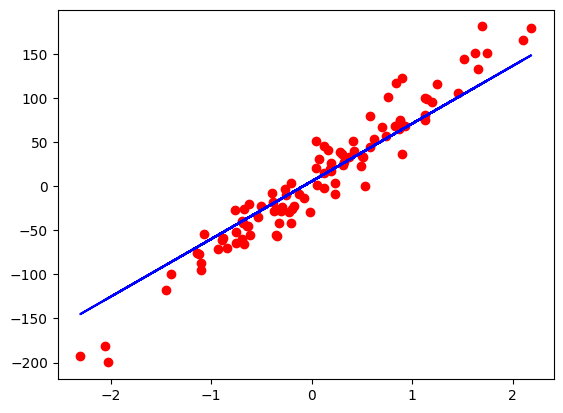

In [ ]:
input_size = n_features
output_size = 1
model = nn.Linear(n_features, 1)
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

num_epochs = 100
for epoch in range(num_epochs):
  y_predicted = model(x)
  loss = criterion(y_predicted, y)

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

  if (epoch+1) % 10 == 0:
    print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')

#PLot
predicted = model(x).detach().numpy()
plt.plot(x_numpy, y_numpy, 'ro')
plt.plot(x_numpy, predicted, 'b')
plt.show()

Logistic Regression

In [ ]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

bc = datasets.load_breast_cancer()
x, y = bc.data, bc.target

n_samples, n_features = x.shape
print(n_samples, n_features)

569 30


In [ ]:
#Data Preprocessing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

x_train = torch.from_numpy(x_train.astype(np.float32))
x_test = torch.from_numpy(x_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

y_train = y_train.view(y_train.shape[0], 1)
y_test = y_test.view(y_test.shape[0], 1)

In [ ]:
class LogModel(nn.Module):
  def __init__(self, n_input_features):
    super(LogModel, self).__init__()
    self.linear = nn.Linear(n_input_features, 1)

  def forward(self, x):
    y_predicted = torch.sigmoid(self.linear(x))
    return y_predicted

model = LogModel(n_features)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
num_epochs = 100

for epoch in range(num_epochs):
  y_predicted = model(x_train)
  loss = criterion(y_predicted, y_train)

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

  if epoch % 10 == 0:
    print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')

epoch: 1, loss = 0.6843
epoch: 11, loss = 0.5364
epoch: 21, loss = 0.4513
epoch: 31, loss = 0.3965
epoch: 41, loss = 0.3581
epoch: 51, loss = 0.3294
epoch: 61, loss = 0.3070
epoch: 71, loss = 0.2888
epoch: 81, loss = 0.2738
epoch: 91, loss = 0.2610


In [ ]:
with torch.no_grad():
  y_predicted = model(x_test)
  y_predicted_cls = y_predicted.round()
  acc = y_predicted_cls.eq(y_test).sum() / float(y_test.shape[0])
  print(f'Accuracy: {acc:.4f}')

Accuracy: 0.9298


Dataset and DataLoader Classes

In [ ]:
"""
The Dataset stores and preprocesses individual data samples and their labels,
while the DataLoader wraps an iterable around the Dataset to provide data in optimized,
mini-batches for training

"""

import torchvision
from torch.utils.data import Dataset, DataLoader
import math

class WineDataset(Dataset):
  def __init__(self):
    # Data loading
    xy = np.loadtxt('/content/wine.csv', delimiter=",", dtype=np.float32, skiprows=1)
    self.x = torch.from_numpy(xy[:, 1:])
    self.y = torch.from_numpy(xy[:, [0]])
    self.n_samples = xy.shape[0]

  def __getitem__(self, index):
    # dataset
    return self.x[index], self.y[index]

  def __len__(self):
    # len(dataset)
    return self.n_samples

dataset = WineDataset()
first_data = dataset[0]
features, labels = first_data
print(features, labels)

tensor([1.4230e+01, 1.7100e+00, 2.4300e+00, 1.5600e+01, 1.2700e+02, 2.8000e+00,
        3.0600e+00, 2.8000e-01, 2.2900e+00, 5.6400e+00, 1.0400e+00, 3.9200e+00,
        1.0650e+03]) tensor([1.])


In [ ]:
dataloader = DataLoader(dataset=dataset, batch_size=4, shuffle=True, num_workers=2)

dataiter = iter(dataloader)
data = next(dataiter)
features, labels = data
print(features, data)

tensor([[1.3500e+01, 1.8100e+00, 2.6100e+00, 2.0000e+01, 9.6000e+01, 2.5300e+00,
         2.6100e+00, 2.8000e-01, 1.6600e+00, 3.5200e+00, 1.1200e+00, 3.8200e+00,
         8.4500e+02],
        [1.2990e+01, 1.6700e+00, 2.6000e+00, 3.0000e+01, 1.3900e+02, 3.3000e+00,
         2.8900e+00, 2.1000e-01, 1.9600e+00, 3.3500e+00, 1.3100e+00, 3.5000e+00,
         9.8500e+02],
        [1.2930e+01, 3.8000e+00, 2.6500e+00, 1.8600e+01, 1.0200e+02, 2.4100e+00,
         2.4100e+00, 2.5000e-01, 1.9800e+00, 4.5000e+00, 1.0300e+00, 3.5200e+00,
         7.7000e+02],
        [1.4220e+01, 1.7000e+00, 2.3000e+00, 1.6300e+01, 1.1800e+02, 3.2000e+00,
         3.0000e+00, 2.6000e-01, 2.0300e+00, 6.3800e+00, 9.4000e-01, 3.3100e+00,
         9.7000e+02]]) [tensor([[1.3500e+01, 1.8100e+00, 2.6100e+00, 2.0000e+01, 9.6000e+01, 2.5300e+00,
         2.6100e+00, 2.8000e-01, 1.6600e+00, 3.5200e+00, 1.1200e+00, 3.8200e+00,
         8.4500e+02],
        [1.2990e+01, 1.6700e+00, 2.6000e+00, 3.0000e+01, 1.3900e+02, 3.3000e+0

In [ ]:
# Dummy Training Loop
num_epochs = 2
total_samples = len(dataset)
n_iterations = math.ceil(total_samples/4)
print(total_samples, n_iterations)

178 45


In [ ]:
for epoch in range(num_epochs):
  for i, (inputs, labels) in enumerate(dataloader):
    if (i+1) % 5 == 0:
      print(f"Epoch: {epoch+1}/{num_epochs}, step {i + 1}/{n_iterations}, inputs {inputs.shape}")

Epoch: 1/2, step 5/45, inputs torch.Size([4, 13])
Epoch: 1/2, step 10/45, inputs torch.Size([4, 13])
Epoch: 1/2, step 15/45, inputs torch.Size([4, 13])
Epoch: 1/2, step 20/45, inputs torch.Size([4, 13])
Epoch: 1/2, step 25/45, inputs torch.Size([4, 13])
Epoch: 1/2, step 30/45, inputs torch.Size([4, 13])
Epoch: 1/2, step 35/45, inputs torch.Size([4, 13])
Epoch: 1/2, step 40/45, inputs torch.Size([4, 13])
Epoch: 1/2, step 45/45, inputs torch.Size([2, 13])
Epoch: 2/2, step 5/45, inputs torch.Size([4, 13])
Epoch: 2/2, step 10/45, inputs torch.Size([4, 13])
Epoch: 2/2, step 15/45, inputs torch.Size([4, 13])
Epoch: 2/2, step 20/45, inputs torch.Size([4, 13])
Epoch: 2/2, step 25/45, inputs torch.Size([4, 13])
Epoch: 2/2, step 30/45, inputs torch.Size([4, 13])
Epoch: 2/2, step 35/45, inputs torch.Size([4, 13])
Epoch: 2/2, step 40/45, inputs torch.Size([4, 13])
Epoch: 2/2, step 45/45, inputs torch.Size([2, 13])
